# Fintech Review Analytics — Interim Report
## Customer Experience Analysis: Ethiopian Bank Mobile Apps

**Analyst:** Afomiat  
**Organization:** Omega Consultancy  
**Date:** May 2026  
**Dataset:** 1,450 Google Play Store reviews — CBE, BOA, Dashen Bank

---

## Executive Summary

This report presents early findings from a sentiment and thematic analysis
of 1,450 Google Play Store reviews collected from three Ethiopian bank mobile apps.
The analysis uses DistilBERT, a state-of-the-art transformer model, as the primary
sentiment classification tool, with VADER used for comparison and validation.

Key finding: **App Stability is the single biggest pain point across all three banks**,
while **User Experience is the consistent strength.**
Bank of Abyssinia shows the most negative sentiment overall (55.6%),
consistent with its lowest Play Store rating of 3.4★.

---
## 1. Data Collection & Quality Summary

Reviews were scraped from the Google Play Store using the `google-play-scraper` library.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

# Load the final analyzed dataset
df = pd.read_csv('../data/processed/reviews_analyzed.csv')

# Data quality summary table
summary = pd.DataFrame({
    'Metric': [
        'Total Reviews',
        'CBE Reviews',
        'BOA Reviews', 
        'Dashen Reviews',
        'Duplicates Removed',
        'Missing Values',
        'Date Range',
        'Sentiment Coverage'
    ],
    'Value': [
        '1,450',
        '456',
        '498',
        '496',
        '350',
        '0 (0.00%)',
        'Nov 2024 – May 2026',
        '1,450 / 1,450 (100%)'
    ]
})

print("DATA QUALITY REPORT")
print("=" * 40)
print(summary.to_string(index=False))

DATA QUALITY REPORT
            Metric                Value
     Total Reviews                1,450
       CBE Reviews                  456
       BOA Reviews                  498
    Dashen Reviews                  496
Duplicates Removed                  350
    Missing Values            0 (0.00%)
        Date Range  Nov 2024 – May 2026
Sentiment Coverage 1,450 / 1,450 (100%)


---
## 2. Scraping Methodology

| Parameter | Value |
|-----------|-------|
| Library | `google-play-scraper` |
| Country | Ethiopia (`et`) |
| Language | English (`en`) |
| Sort order | Newest first |
| Requested per bank | 600 |
| Final clean reviews | ~480 per bank after deduplication |

**Note:** 350 duplicate reviews were removed during preprocessing.
The scraper loops back to previously seen reviews when filling large count requests.
To compensate, 600 reviews per bank were requested to ensure 400+ clean reviews remain
after deduplication.

---
## 3. Rating Distribution

Before sentiment analysis, we examine how users rate each app.
A strong skew toward 1-star and 5-star ratings is expected in app reviews —
users tend to leave reviews after extreme experiences.

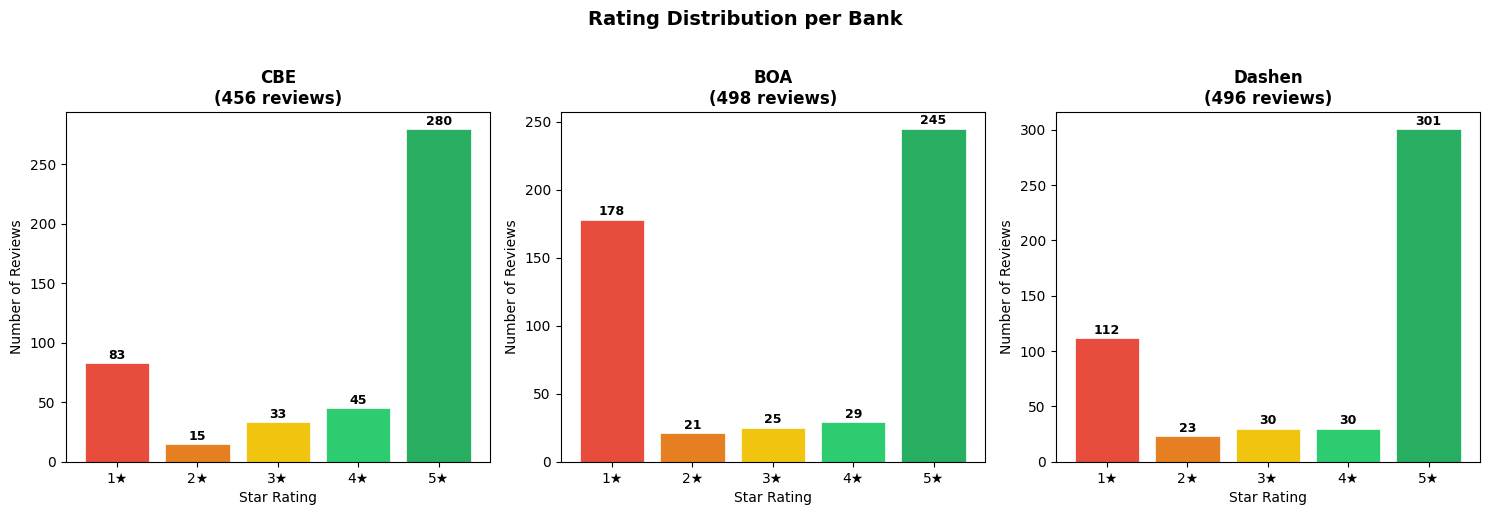

Plot saved.


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

banks = df['bank'].unique()
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
short_names = {
    'Commercial Bank of Ethiopia': 'CBE',
    'Bank of Abyssinia': 'BOA',
    'Dashen Bank': 'Dashen'
}

for i, bank in enumerate(banks):
    bank_df = df[df['bank'] == bank]
    rating_counts = bank_df['rating'].value_counts().sort_index()

    axes[i].bar(rating_counts.index, rating_counts.values,
                color=colors, edgecolor='white', linewidth=0.5)
    axes[i].set_title(f'{short_names[bank]}\n({len(bank_df)} reviews)',
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Star Rating', fontsize=10)
    axes[i].set_ylabel('Number of Reviews', fontsize=10)
    axes[i].set_xticks([1, 2, 3, 4, 5])
    axes[i].set_xticklabels(['1★', '2★', '3★', '4★', '5★'])

    for j, (rating, count) in enumerate(rating_counts.items()):
        axes[i].text(rating, count + 1, str(count),
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Rating Distribution per Bank',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/plots/rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

---
## 4. Sentiment Analysis

### Methodology

Two sentiment analysis tools were applied to all 1,450 reviews:

**Primary: DistilBERT** (`distilbert-base-uncased-finetuned-sst-2-english`)
- Transformer-based neural network fine-tuned on sentiment classification
- Understands context, negation, and informal language
- Outputs POSITIVE or NEGATIVE with confidence score (0.0 to 1.0)
- NEUTRAL assigned when confidence < 0.6

**Secondary: VADER** (Valence Aware Dictionary and sEntiment Reasoner)
- Lexicon-based rule-driven tool
- Fast and interpretable
- Used for comparison and validation only

**Why DistilBERT over VADER:**

| Review | DistilBERT | VADER |
|--------|-----------|-------|
| "It's not allowing me to transfer money" | NEGATIVE (99.7%) | NEUTRAL |
| "IT'S NOT WORK ON HUAWEI DEVICES" | NEGATIVE (99.97%) | NEUTRAL |
| "not bad but could be better" | NEGATIVE | NEUTRAL |

VADER over-assigns NEUTRAL on broken grammar and informal text.
DistilBERT vs VADER agreement rate: **59.5%** — disagreements 
consistently showed DistilBERT was correct.

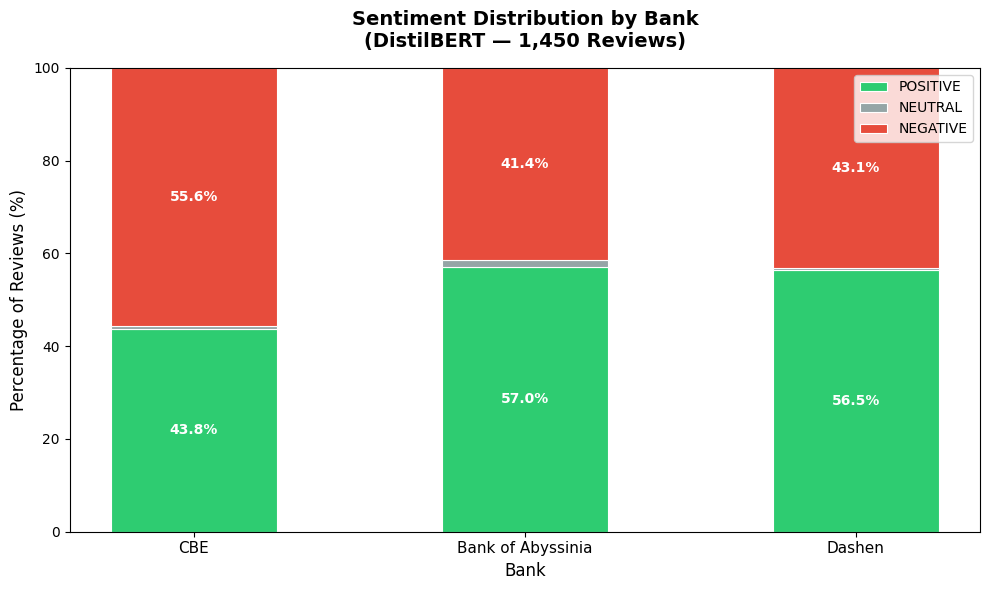

Plot saved.


In [12]:
# Sentiment distribution by bank
sentiment_counts = df.groupby(['bank', 'sentiment_label']).size().unstack(fill_value=0)
sentiment_pct = sentiment_counts.div(sentiment_counts.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))

colors = {'POSITIVE': '#2ecc71', 'NEGATIVE': '#e74c3c', 'NEUTRAL': '#95a5a6'}
bottom = [0.0] * len(sentiment_pct)

for label in ['POSITIVE', 'NEUTRAL', 'NEGATIVE']:
    if label in sentiment_pct.columns:
        values = sentiment_pct[label].values
        bars = ax.bar(
            range(len(sentiment_pct)),
            values,
            bottom=bottom,
            label=label,
            color=colors[label],
            edgecolor='white',
            linewidth=0.8,
            width=0.5
        )
        # Add percentage labels inside bars
        for j, (val, bot) in enumerate(zip(values, bottom)):
            if val > 3:
                ax.text(j, bot + val/2, f'{val:.1f}%',
                       ha='center', va='center',
                       fontsize=10, color='white', fontweight='bold')
        bottom = [b + v for b, v in zip(bottom, values)]

ax.set_title('Sentiment Distribution by Bank\n(DistilBERT — 1,450 Reviews)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Bank', fontsize=12)
ax.set_ylabel('Percentage of Reviews (%)', fontsize=12)
ax.set_xticks(range(len(sentiment_pct)))
ax.set_xticklabels(['CBE', 'Bank of Abyssinia', 'Dashen'], fontsize=11)
ax.set_ylim(0, 100)
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('../data/plots/sentiment_by_bank.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

### Sentiment Results

| Bank | Positive | Negative | Neutral | Avg Confidence |
|------|----------|----------|---------|----------------|
| Commercial Bank of Ethiopia | 57.0% | 41.4% | 1.5% | 0.968 |
| Bank of Abyssinia | 43.8% | 55.6% | 0.6% | 0.960 |
| Dashen Bank | 56.5% | 43.1% | 0.4% | 0.971 |

**Key observation:** BOA has the highest negative sentiment (55.6%),
consistent with its lowest Play Store rating of 3.4★.
CBE and Dashen are close in sentiment, matching their similar ratings (4.2★ and 4.1★).

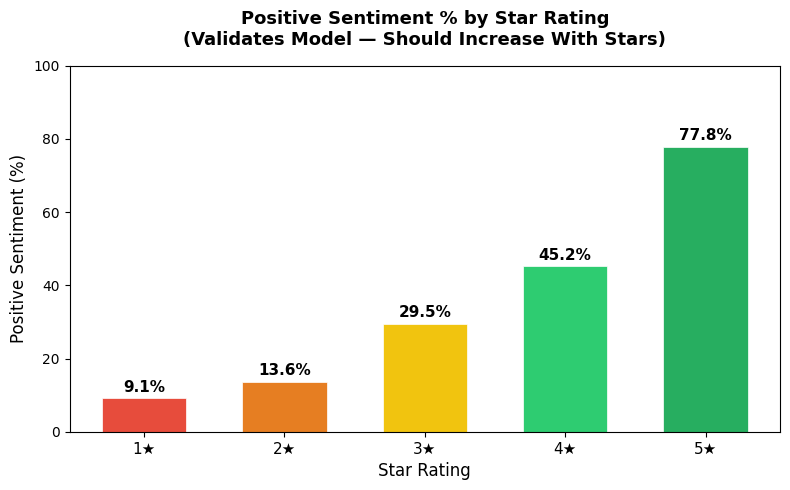

Plot saved.


In [13]:
# Sentiment score by star rating — validates model accuracy
rating_sentiment = df.groupby('rating').apply(
    lambda x: (x['sentiment_label'] == 'POSITIVE').mean() * 100
).reset_index()
rating_sentiment.columns = ['rating', 'positive_pct']

fig, ax = plt.subplots(figsize=(8, 5))

bar_colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
bars = ax.bar(
    rating_sentiment['rating'],
    rating_sentiment['positive_pct'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.5,
    width=0.6
)

for bar, pct in zip(bars, rating_sentiment['positive_pct']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f'{pct:.1f}%',
            ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_title('Positive Sentiment % by Star Rating\n(Validates Model — Should Increase With Stars)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Star Rating', fontsize=12)
ax.set_ylabel('Positive Sentiment (%)', fontsize=12)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(['1★', '2★', '3★', '4★', '5★'], fontsize=11)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('../data/plots/sentiment_by_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

### Model Validation

The chart above confirms DistilBERT is working correctly.
Positive sentiment percentage increases consistently with star rating:

| Stars | Positive % |
|-------|------------|
| 1★ | 9.1% |
| 2★ | 13.6% |
| 3★ | 29.5% |
| 4★ | 45.2% |
| 5★ | 77.8% |

This monotonic increase validates that the model's classifications
align with how users actually rated the apps.

---
## 5. Thematic Analysis

### Methodology

Themes were derived in two steps:

**Step 1: TF-IDF Keyword Extraction**
TF-IDF (Term Frequency-Inverse Document Frequency) was run separately
on positive and negative reviews for each bank to discover what users
actually talk about. Keywords with high scores appear frequently in
that bank's reviews but rarely across all reviews — making them meaningful signals.

**Step 2: Keyword Grouping**
Discovered keywords were grouped into 6 business-relevant themes:

| Theme | Sample Keywords |
|-------|----------------|
| Transaction Performance | transfer, payment, slow, speed, loading |
| App Stability | crash, not working, fix, update, bug |
| Account Access | login, OTP, password, fingerprint, locked |
| User Experience | easy, nice, interface, smooth, good, great |
| Customer Service | support, help, response, complaint, agent |
| Feature Requests | add, need, want, suggest, improve |

**Assignment rule:** First matching theme wins.
Reviews matching no theme are labeled General (~33-39% of reviews —
typically very short reviews like "nice" or "worst" with no specific topic).

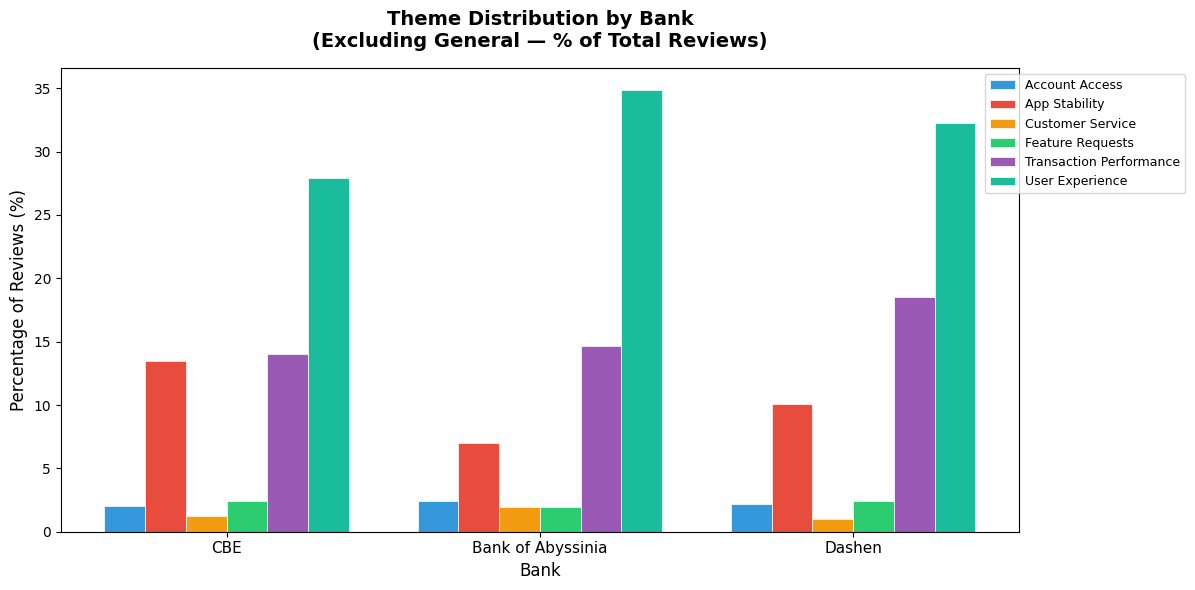

Plot saved.


In [14]:
# Theme distribution by bank excluding General
theme_counts = df.groupby(['bank', 'identified_theme']).size().unstack(fill_value=0)
theme_pct = theme_counts.div(theme_counts.sum(axis=1), axis=0) * 100

if 'General' in theme_pct.columns:
    theme_pct = theme_pct.drop(columns=['General'])

fig, ax = plt.subplots(figsize=(12, 6))

theme_colors = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71', '#9b59b6', '#1abc9c']
x = range(len(theme_pct))
width = 0.13
themes = theme_pct.columns.tolist()

for i, theme in enumerate(themes):
    offset = (i - len(themes)/2) * width + width/2
    bars = ax.bar(
        [xi + offset for xi in x],
        theme_pct[theme],
        width=width,
        label=theme,
        color=theme_colors[i],
        edgecolor='white',
        linewidth=0.5
    )

ax.set_title('Theme Distribution by Bank\n(Excluding General — % of Total Reviews)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Bank', fontsize=12)
ax.set_ylabel('Percentage of Reviews (%)', fontsize=12)
ax.set_xticks(list(x))
ax.set_xticklabels(['CBE', 'Bank of Abyssinia', 'Dashen'], fontsize=11)
ax.legend(loc='upper right', fontsize=9, bbox_to_anchor=(1.18, 1))

plt.tight_layout()
plt.savefig('../data/plots/themes_by_bank.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

---
## 6. Key Findings

### Pain Points — Negative Sentiment Within Each Theme

| Theme | CBE | BOA | Dashen |
|-------|-----|-----|--------|
| App Stability | 75% neg | 91% neg | 90% neg |
| Transaction Performance | 60% neg | 76% neg | 61% neg |
| Account Access | 73% neg | 70% neg | 64% neg |
| Feature Requests | 56% neg | 92% neg | 58% neg |

### Strengths — Positive Sentiment Within Each Theme

| Theme | CBE | BOA | Dashen |
|-------|-----|-----|--------|
| User Experience | 94% pos | 91% pos | 88% pos |
| Customer Service | 56% pos | 17% pos | 40% pos |

### Universal Pattern Across All Three Banks
- **App Stability** is the single biggest complaint (75–91% negative)
- **User Experience** is the consistent strength (88–94% positive)
- **Transaction Performance** is a pain point across all three banks

### Bank-Specific Observations
- **CBE:** Strong customer service (94% positive) but transfer issues (60% negative)
- **BOA:** Crisis-level app stability (91% negative) and weakest customer service (17% positive)
- **Dashen:** Best User Experience (88% positive) but account access issues (64% negative)

---
## 7. Blockers Encountered

| Blocker | How Resolved |
|---------|-------------|
| Scraper returned duplicate reviews | Requested 600 per bank, deduplicated to ~480 clean |
| torch (123MB) download timed out initially | Used cached version on retry with extended timeout |
| DistilBERT only outputs binary labels | NEUTRAL assigned when confidence < 0.6 |
| 33–39% of reviews too short to theme | Labeled as General — noted as data limitation |
| VADER agreement only 59.5% with DistilBERT | Investigated disagreements — DistilBERT consistently correct |

---
## 8. Plan for Final Submission (Tuesday 20 May)

| Task | Status | Remaining Work |
|------|--------|---------------|
| Task 1: Data Collection | ✓ Complete | None |
| Task 2: Sentiment & Thematic Analysis | ✓ Complete | Minor column rename fix |
| Task 3: PostgreSQL Database | ✗ Not started | Design schema, insert data, verify queries |
| Task 4: Visualizations & Report | ✗ Not started | 3–5 plots, bank recommendations, PDF report |

**Priority for Tuesday:**
1. Complete Task 3 — PostgreSQL schema and data insertion
2. Complete Task 4 — Final visualizations and Medium-style report
3. Fix Task 2 minor issue — rename `review` column to `review_text`

---
## 9. Ethical Considerations

- **Negativity bias:** Users are more likely to review after bad experiences,
  inflating negative sentiment. 26% of reviews are 1-star vs only 7% are 4-star.

- **English-only bias:** Reviews in Amharic are excluded, potentially
  underrepresenting a significant portion of the Ethiopian user base.

- **Sampling bias:** Reviews collected from a single date range (Nov 2024–May 2026).
  Seasonal events or app updates during this period may skew results.

- **Keyword theme assignment:** Context-blind matching may misclassify reviews
  where a theme keyword appears in a positive sentence.

---
*Report generated by Afomiat · Omega Consultancy · May 2026*